# 03 · Sequences: all steps must work

## Learning objectives

- Implement sequence propagation.
- Compare reactive and memory sequences.
- Identify skipped children.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

A **sequence** means “do these in order.” It succeeds only when every child succeeds.
It immediately returns the first FAILURE or RUNNING. An empty sequence succeeds: there
are no remaining requirements. A **reactive** sequence starts from the first child on every
tick. A **memory** sequence resumes at the child that was running. Memory saves repeated
work but can skip a condition that has changed.

In [2]:
from behavior_trees_tutorial.trees.core import Action, Sequence, Selector, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display

## Minimal working example
The package contains the same tiny engine from lessons 1–2. This function exposes the
sequence rule before we introduce the state needed for memory.

In [3]:
def sequence_tick(children):
    for child in children:
        result = child.tick()
        if result is not Status.SUCCESS:
            return result
    return Status.SUCCESS

safe = {"value": True}
check = Action("Safe?", lambda: Status.SUCCESS if safe["value"] else Status.FAILURE)
work = Action("Move", lambda: Status.RUNNING)
assert sequence_tick([check, work]) is Status.RUNNING

## Step-by-step implementation
`Sequence` adds an index to remember the running child. Starting at zero gives reactive
semantics. Starting at the saved index gives memory semantics. Children to the right of
a stopped branch become inactive. Our teaching engine only resets status; it does not
cancel real external work. Lesson 7 introduces lifecycle hooks for that purpose.

class Sequence:
    """Stop at the first child that does not succeed."""

    def __init__(self, name, children, memory=False):
        self.name, self.children, self.memory = name, children, memory
        self.status = Status.INVALID
        self.index = 0

    def tick(self):
        start = self.index if self.memory and self.status is Status.RUNNING else 0
        for index in range(start, len(self.children)):
            result = self.children[index].tick()
            if result is not Status.SUCCESS:
                for child in self.children[index + 1:]:
                    child.reset()
                self.index, self.status = index, result
                return result
        self.status = Status.SUCCESS
        return self.status

    def reset(self):
        self.status, self.index = Status.INVALID, 0
        for child in self.children:
            child.reset()



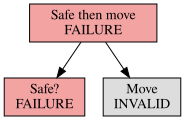

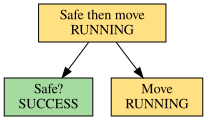

In [4]:
import inspect
print(inspect.getsource(Sequence))

def make_sequence(memory=False):
    return Sequence("Safe then move", [
        Action("Safe?", lambda: Status.SUCCESS if safe["value"] else Status.FAILURE),
        Action("Move", lambda: Status.RUNNING),
    ], memory=memory)

reactive, remembered = make_sequence(), make_sequence(memory=True)
reactive.tick(); remembered.tick()
safe["value"] = False
assert reactive.tick() is Status.FAILURE
assert remembered.tick() is Status.RUNNING
for tree in (reactive, remembered):
    display(diagram(tree))

## Interactive demonstration
Flip the condition and compare the second tick. The slider callback builds fresh trees.

In [5]:
import ipywidgets as widgets

@widgets.interact(memory=False, safe_after_first_tick=False)
def compare(memory=False, safe_after_first_tick=False):
    safe["value"] = True
    tree = make_sequence(memory)
    trace(tree, 1)
    safe["value"] = safe_after_first_tick
    trace(tree, 1)
    display(diagram(tree))

interactive(children=(Checkbox(value=False, description='memory'), Checkbox(value=False, description='safe_aft…

## Key observations

Memory is a control-flow choice. It is unsuitable for a safety condition that must be rechecked while an action runs.

## Exercises

1. Add a third child and prove it is skipped when child 2 runs.
2. Check the result for an empty sequence.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 03).

## Summary

A sequence combines requirements. Next we need a rule for alternatives.